In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pycorr 
import pandas as pd
from matplotlib.gridspec import GridSpec
from scipy.interpolate import UnivariateSpline

In [6]:
plt.style.use("astroandes.mplstyle")

In [7]:
def web_classification(n_data, n_random):
    assert len(n_data) == len(n_random)
    n_points = len(n_data)
    r_values = (n_data-n_random)/(n_data+n_random)
    web_class = np.zeros(n_points, dtype=int)
    lower_limit = -0.90
    upper_limit = 0.90
    is_void = r_values <= lower_limit
    is_sheet = (r_values > lower_limit) & (r_values<=0.0)
    is_filament = (r_values>0.0) & (r_values <= upper_limit)
    is_peak = (r_values > upper_limit)
    web_class[is_void] = 0
    web_class[is_sheet] = 1
    web_class[is_filament] = 2
    web_class[is_peak] = 3
    return web_class  

import numpy as np

def rotate_points_clockwise(X, Y, angle_degrees=135):
    """
    Rotate points (X, Y) clockwise around the origin by the specified angle.
    
    Parameters:
    -----------
    X, Y : numpy arrays or lists
        The x and y coordinates to rotate
    angle_degrees : float
        The angle in degrees to rotate clockwise
        
    Returns:
    --------
    X_rotated, Y_rotated : numpy arrays
        The rotated coordinates
    """
    # Convert angle to radians (positive for clockwise rotation)
    angle_radians = np.radians(angle_degrees)
    
    # Rotation matrix components
    cos_theta = np.cos(angle_radians)
    sin_theta = np.sin(angle_radians)
    
    # Apply rotation
    X_rotated = X * cos_theta + Y * sin_theta
    Y_rotated = -X * sin_theta + Y * cos_theta
    
    return X_rotated, Y_rotated

In [8]:
webs_data = {}
webs_random = {}
pos_data = {}
pos_random = {}

# TCW classification
tweb_data = np.loadtxt('../data/TCW/tcw_web/web_type_tweb.txt')
p_data = np.loadtxt('../data/TCW/pos/fof_catalog_200Mpc512_xyz.dat')
p_rand = np.loadtxt("../data/TCW/pos/random_000_fof_catalog_200Mpc512_xyz.dat")
hubble = 0.68
p_data = p_data[:,0:3]/hubble
p_rand = p_rand[:,0:3]/hubble
n_con_random = np.loadtxt("../data/TCW/web/random_000_fof_catalog_200Mpc512_xyz_fof_catalog_200Mpc512_xyz_nconnections.dat")
n_con_data = np.loadtxt("../data/TCW/web/fof_catalog_200Mpc512_xyz_random_000_fof_catalog_200Mpc512_xyz_nconnections.dat")
webs_data['TCW'] = web_classification(n_con_data[:,0], n_con_data[:,1])
webs_random['TCW'] = web_classification(n_con_random[:,0], n_con_random[:,1])
pos_data['TCW'] = p_data.copy()
pos_random['TCW'] = p_rand.copy()

# TNG classifications
p_data = np.loadtxt("../data/TNG/TNG300-1/pos/subhalo_massive_xyz.dat")
p_rand = np.loadtxt("../data/TNG/TNG300-1/pos/random_000_subhalo_massive_xyz.dat")
hubble=0.6774
p_data[:,0:3] = p_data[:,0:3]/1000.0/hubble
p_rand[:,0:3] = p_rand[:,0:3]/1000.0/hubble
n_con_random = np.loadtxt("../data/TNG/TNG300-1/web/random_000_subhalo_massive_xyz_subhalo_massive_xyz_nconnections.dat")
n_con_data = np.loadtxt("../data/TNG/TNG300-1/web/subhalo_massive_xyz_random_000_subhalo_massive_xyz_nconnections.dat")
webs_data['TNG'] = web_classification(n_con_data[:,0], n_con_data[:,1])
webs_random['TNG'] = web_classification(n_con_random[:,0], n_con_random[:,1])
pos_data['TNG'] = p_data.copy()
pos_random['TNG'] = p_rand.copy()

#SDSS classification
p_data = np.loadtxt("../data/SDSS/pos/mag_r_limited_xyz.dat")
p_rand = np.loadtxt("../data/SDSS/pos/random_000_mag_r_limited_xyz.dat")
p_data = p_data[:,0:3]
p_rand = p_rand[:,0:3]
p_data[:,0], p_data[:,1] = rotate_points_clockwise(p_data[:,0], p_data[:,1])
p_rand[:,0], p_rand[:,1] = rotate_points_clockwise(p_rand[:,0], p_rand[:,1])

n_con_random = np.loadtxt("../data/SDSS/web/random_000_mag_r_limited_xyz_mag_r_limited_xyz_nconnections.dat")
n_con_data = np.loadtxt("../data/SDSS/web/mag_r_limited_xyz_random_000_mag_r_limited_xyz_nconnections.dat")

webs_data['SDSS'] = web_classification(n_con_data[:,0], n_con_data[:,1])
webs_random['SDSS'] = web_classification(n_con_random[:,0], n_con_random[:,1])
pos_data['SDSS'] = p_data.copy()
pos_random['SDSS'] = p_rand.copy()

/tmp/ipykernel_1359308/96062192.py:246: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


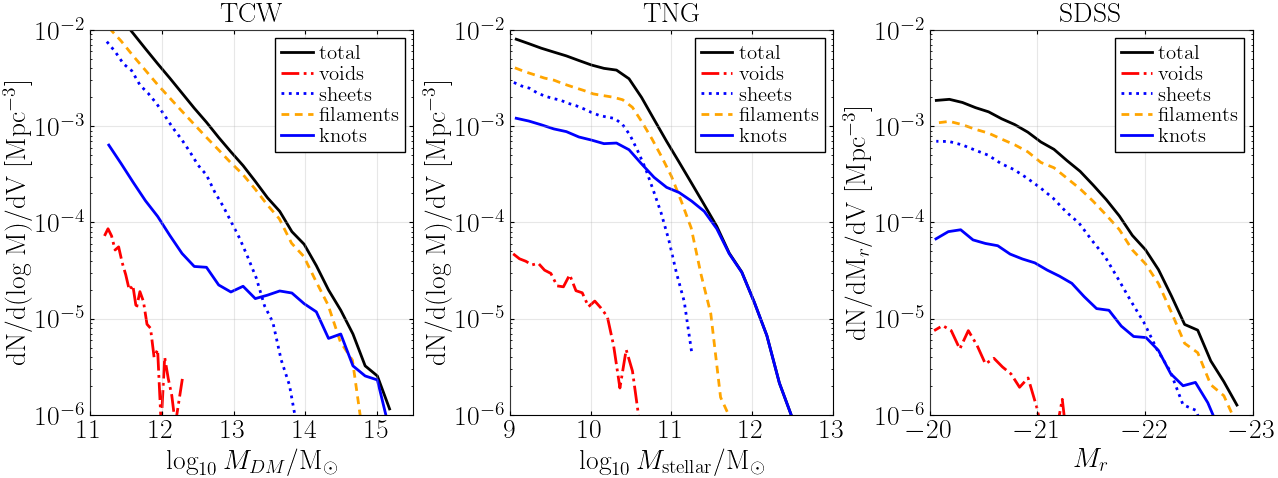

In [33]:
def compute_mass_function(masses, web_classes, mass_bins=None, volume=None, web_type=None):
    """
    Compute the mass function (number density vs mass) for a given cosmic web type.
    
    Parameters:
    -----------
    masses : array
        Array of masses
    web_classes : array
        Array of web classifications (0=void, 1=sheet, 2=filament, 3=knot)
    mass_bins : array, optional
        Mass bin edges. If None, will create logarithmic bins
    volume : float, optional
        Survey volume in (Mpc/h)^3. If None, will use normalized counts
    web_type : int, optional
        Web type to select (0-3). If None, uses all points
        
    Returns:
    --------
    mass_centers : array
        Centers of mass bins
    number_density : array
        Number density dN/dlogM [h^3/Mpc^3]
    """
    # Select points based on web type
    if web_type is not None:
        mask = web_classes == web_type
        selected_masses = masses[mask]
    else:
        selected_masses = masses
    
    # Remove zero or negative masses
    selected_masses = selected_masses[selected_masses > 0]
    
    if len(selected_masses) == 0:
        return np.array([]), np.array([])
    
    # Create logarithmic mass bins if not provided
    if mass_bins is None:
        log_min = np.log10(np.min(selected_masses))
        log_max = np.log10(np.max(selected_masses))
        mass_bins = np.logspace(log_min, log_max, 25)
    
    # Compute histogram
    counts, bin_edges = np.histogram(selected_masses, bins=mass_bins)
    
    # Calculate bin centers and widths
    mass_centers = np.sqrt(bin_edges[:-1] * bin_edges[1:])  # Geometric mean
    log_mass_centers = np.log10(mass_centers)
    dlogM = np.diff(np.log10(bin_edges))
    
    # Calculate number density
    if volume is not None:
        number_density = counts / (volume * dlogM)
    else:
        number_density = counts / dlogM
    
    # Remove bins with zero counts
    mask = counts > 0
    
    return log_mass_centers[mask], number_density[mask]

def compute_luminosity_function(magnitudes, web_classes, mag_bins=None, volume=None, web_type=None):
    """
    Compute the luminosity function for a given cosmic web type.
    
    Parameters:
    -----------
    magnitudes : array
        Array of magnitudes
    web_classes : array
        Array of web classifications
    mag_bins : array, optional
        Magnitude bin edges
    volume : float, optional
        Survey volume
    web_type : int, optional
        Web type to select
        
    Returns:
    --------
    mag_centers : array
        Centers of magnitude bins
    number_density : array
        Number density dN/dM [h^3/Mpc^3/mag]
    """
    # Select points based on web type
    if web_type is not None:
        mask = web_classes == web_type
        selected_mags = magnitudes[mask]
    else:
        selected_mags = magnitudes
    
    if len(selected_mags) == 0:
        return np.array([]), np.array([])
    
    # Create magnitude bins if not provided
    if mag_bins is None:
        mag_min = np.min(selected_mags)
        mag_max = np.max(selected_mags)
        mag_bins = np.linspace(mag_min, mag_max, 25)
    
    # Compute histogram
    counts, bin_edges = np.histogram(selected_mags, bins=mag_bins)
    
    # Calculate bin centers and widths
    mag_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    dM = np.diff(bin_edges)
    
    # Calculate number density
    if volume is not None:
        number_density = counts / (volume * dM)
    else:
        number_density = counts / dM
    
    # Remove bins with zero counts
    mask = counts > 0
    
    return mag_centers[mask], number_density[mask]

def plot_mass_luminosity_functions(pos_data, webs_data, output_filename='mass_luminosity_functions.pdf'):
    """
    Create mass and luminosity function plots for different cosmic web environments.
    
    Parameters:
    -----------
    pos_data : dict
        Dictionary containing position and mass/magnitude data
    webs_data : dict
        Dictionary containing web classifications
    output_filename : str
        Output filename for the plot
    """
    
    # Set up the plot
    fig = plt.figure(figsize=(15, 5))
    gs = GridSpec(1, 3, figure=fig, hspace=0.3, wspace=0.3)
    
    # Define colors and labels for web types
    web_colors = ['red', 'blue', 'orange', 'blue']  # void, sheet, filament, knot
    web_labels = ['voids', 'sheets', 'filaments', 'knots']
    web_linestyles = ['-.', ':', '--', '-']
    
    datasets = list(pos_data.keys())
    
    # Plot 1: TCW Halo Mass Function
    ax1 = fig.add_subplot(gs[0, 0])
    
    # Load TCW data with masses
    hubble = 0.68
    tcw_data = np.loadtxt('../data/TCW/pos/fof_catalog_200Mpc512_xyz.dat')
    tcw_masses = tcw_data[:, 3]/hubble  # 4th column is mass in Msun/h
    tcw_web = webs_data['TCW']
    
    # Estimate volume (200 Mpc/h)^3
    tcw_volume = (200/hubble)**3
    
    # Plot total mass function
    log_m_total, nd_total = compute_mass_function(tcw_masses, tcw_web, volume=tcw_volume)
    ax1.plot(log_m_total, nd_total, 'k-', linewidth=2, label='total')
    
    # Plot mass functions for each web type
    for web_type in range(4):
        log_m, nd = compute_mass_function(tcw_masses, tcw_web, volume=tcw_volume, web_type=web_type)
        if len(log_m) > 0:
            ax1.plot(log_m, nd, color=web_colors[web_type], linestyle=web_linestyles[web_type], 
                    linewidth=2, label=web_labels[web_type])
    
    ax1.set_xlabel(r'$\log_{10} M_{DM}$/M$_{\odot}$')
    ax1.set_ylabel(r'dN/d(log M)/dV [Mpc$^{-3}$]')
    ax1.set_yscale('log')
    ax1.set_title('TCW')

    ax1.set_xlim(11, 15.5)
    ax1.set_ylim(1e-6, 1e-2)
    ax1.set_xticks(np.arange(11,16))
    ax1.legend(fontsize=15)
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: TNG Stellar Mass Function
    ax2 = fig.add_subplot(gs[0, 1])
    
    # Load TNG data with stellar masses
    tng_data = np.loadtxt('../data/TNG/TNG300-1/pos/subhalo_massive_xyz.dat')
    tng_masses = tng_data[:, 3] * 1e10  # Convert to solar masses (given in 10^10 Msun)
    tng_web = webs_data['TNG']
    
    # TNG volume (300 Mpc)^3
    tng_volume = 300**3
    
    # Plot total stellar mass function
    log_m_total, nd_total = compute_mass_function(tng_masses, tng_web, volume=tng_volume)
    ax2.plot(log_m_total, nd_total, 'k-', linewidth=2, label='total')
    
    # Plot stellar mass functions for each web type
    for web_type in range(4):
        log_m, nd = compute_mass_function(tng_masses, tng_web, volume=tng_volume, web_type=web_type)
        if len(log_m) > 0:
            ax2.plot(log_m, nd, color=web_colors[web_type], linestyle=web_linestyles[web_type], 
                    linewidth=2, label=web_labels[web_type])
    
    ax2.set_xlabel(r'$\log_{10} M_{\mathrm{stellar}}$/M$_{\odot}$')
    ax2.set_ylabel(r'dN/d(log M)/dV [Mpc$^{-3}$]')
    ax2.set_yscale('log')
    ax2.set_title('TNG')
    ax2.set_xticks(np.arange(9,14))
    ax2.set_xlim(9, 13)
    ax2.set_ylim(1e-6, 1e-2)
    ax2.legend(fontsize=15)
    ax2.grid(True, alpha=0.3)
    
    # Plot 3: SDSS Luminosity Function
    ax3 = fig.add_subplot(gs[0, 2])
    
    # Load SDSS data with magnitudes
    sdss_data = np.loadtxt('../data/SDSS/pos/mag_r_limited_xyz.dat')
    sdss_mags = sdss_data[:, 3]  # 4th column is r-band magnitude
    sdss_web = webs_data['SDSS']
    
    # SDSS survey volume (approximate)
    # This would need to be calculated based on the actual survey geometry
    # For now, use a rough estimate
    sdss_volume = 5.2E7  # Approximate volume in (Mpc)^3
    
    # Plot total luminosity function
    mag_total, nd_total = compute_luminosity_function(sdss_mags, sdss_web, volume=sdss_volume)
    ax3.plot(mag_total, nd_total, 'k-', linewidth=2, label='total')
    
    # Plot luminosity functions for each web type
    for web_type in range(4):
        mag, nd = compute_luminosity_function(sdss_mags, sdss_web, volume=sdss_volume, web_type=web_type)
        if len(mag) > 0:
            ax3.plot(mag, nd, color=web_colors[web_type], linestyle=web_linestyles[web_type], 
                    linewidth=2, label=web_labels[web_type])
    
    ax3.set_xlabel(r'$M_r$')
    ax3.set_ylabel(r'dN/dM$_r$/dV [Mpc$^{-3}$]')
    ax3.set_yscale('log')
    ax3.set_title('SDSS')
    ax3.set_xlim(-23, -20)
    ax3.set_ylim(1e-6, 1e-2)
    ax3.invert_xaxis()  # Invert x-axis for magnitude plot
    ax3.legend(fontsize=15)
    ax3.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(output_filename, dpi=300, bbox_inches='tight')
    
    return 

# Call the function
plot_mass_luminosity_functions(pos_data, webs_data)